11490434/11490434 [==============================] - 0s 0us/step
True Label: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


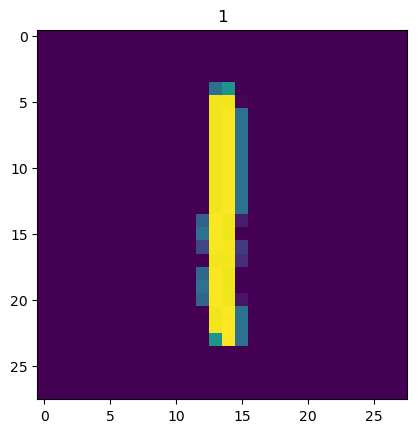

In [1]:
import keras
import numpy as np
from keras.utils import np_utils
from keras.datasets import mnist
from tensorflow.keras import Sequential
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Dense, Activation, Conv2D, MaxPooling2D, Flatten
import matplotlib.pyplot as plt
import seaborn as sns
import random
random.seed(10)

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Display an image from training set
i=102
plt.imshow(x_train[i])  
plt.title(y_train[i])

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
print('True Label:',y_train[i])

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

In [4]:
print(y_test)

[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [2]:
model = Sequential(name='MNIST_CNN')

model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=(28, 28)))
model.add(keras.layers.Dropout(0.25))
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dropout(0.25))
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dropout(0.25))
model.add(keras.layers.Dense(10, activation="softmax"))

opt = optimizers.SGD(learning_rate=0.01)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

hist = model.fit(x_train, y_train,
                 epochs=5,
                 batch_size=256,
                 validation_data=(x_test, y_test))

Epoch 1/5
235/235 [==============================] - 3s 9ms/step - loss: 1.9064 - accuracy: 0.4053 - val_loss: 1.2157 - val_accuracy: 0.7472
Epoch 2/5
235/235 [==============================] - 2s 8ms/step - loss: 1.0918 - accuracy: 0.6856 - val_loss: 0.6629 - val_accuracy: 0.8407
Epoch 3/5
235/235 [==============================] - 2s 8ms/step - loss: 0.7881 - accuracy: 0.7571 - val_loss: 0.5065 - val_accuracy: 0.8687
Epoch 4/5
235/235 [==============================] - 2s 8ms/step - loss: 0.6734 - accuracy: 0.7896 - val_loss: 0.4354 - val_accuracy: 0.8829
Epoch 5/5
235/235 [==============================] - 2s 8ms/step - loss: 0.6043 - accuracy: 0.8142 - val_loss: 0.3946 - val_accuracy: 0.8934


In [7]:
#obtain model predictions without dropout 

output = model.predict(x_test)
ModelGuesses = np.argmax(output,axis=1)
TrueLabels = np.argmax(y_test,axis=1)

WhichAreWrong=np.where(ModelGuesses!=TrueLabels)[0]
print('Number of test guess wrong = ',len(WhichAreWrong),'out of',len(y_test))

Number of test guess wrong =  1066 out of 10000


In [4]:
#obtain model predictions with dropout 

def predict_proba(X, model, num_samples):
    preds = [model(X, training=True) for _ in range(num_samples)]
    return np.stack(preds).mean(axis=0)
     
y_pred_proba = predict_proba(x_test, model, 100)

In [5]:
pred_dropout = np.round(y_pred_proba, 3)
pred_nodrop = np.round(output, 3)

In [6]:
i=102
print("Uncertainty vector using MC dropout:")
print(pred_dropout[i])
print("Uncertainty vector without dropout:")
print(pred_nodrop[i])

#with dropout, there is greater uncertainty 

Uncertainty vector using MC dropout:
[0.016 0.    0.    0.033 0.004 0.826 0.    0.031 0.054 0.036]
Uncertainty vector without dropout:
[0.005 0.    0.    0.012 0.001 0.936 0.    0.006 0.028 0.012]


True label [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


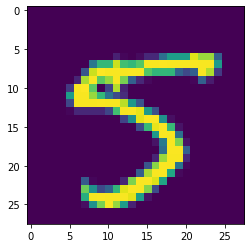

In [89]:
plt.imshow(x_test[i])  
print('True label',y_test[i])

In [11]:
from keras.datasets import boston_housing
(Xtrain, Ytrain), (Xtest, Ytest) = boston_housing.load_data()

In [12]:
model = keras.models.Sequential()
model.add(keras.layers.Dropout(0.1))
model.add(keras.layers.Dense(128, activation="relu"))
model.add(keras.layers.Dropout(0.1))
model.add(keras.layers.Dense(64, activation="relu"))
model.add(keras.layers.Dropout(0.1))
model.add(keras.layers.Dense(1, activation="relu"))

opt = optimizers.Nadam(learning_rate=0.001)
model.compile(loss="mse", optimizer=opt)
model.fit(Xtrain, Ytrain, epochs=30, validation_split=0.1)

Epoch 1/30
12/12 [==============================] - 1s 13ms/step - loss: 415.8818 - val_loss: 58.7791
Epoch 2/30
12/12 [==============================] - 0s 5ms/step - loss: 360.6644 - val_loss: 164.9393
Epoch 3/30
12/12 [==============================] - 0s 5ms/step - loss: 283.6061 - val_loss: 97.1149
Epoch 4/30
12/12 [==============================] - 0s 5ms/step - loss: 278.4530 - val_loss: 25.1422
Epoch 5/30
12/12 [==============================] - 0s 5ms/step - loss: 222.9472 - val_loss: 47.9988
Epoch 6/30
12/12 [==============================] - 0s 5ms/step - loss: 194.4998 - val_loss: 120.7750
Epoch 7/30
12/12 [==============================] - 0s 7ms/step - loss: 191.4942 - val_loss: 30.1431
Epoch 8/30
12/12 [==============================] - 0s 7ms/step - loss: 165.7812 - val_loss: 114.1195
Epoch 9/30
12/12 [==============================] - 0s 7ms/step - loss: 177.1374 - val_loss: 23.2840
Epoch 10/30
12/12 [==============================] - 0s 6ms/step - loss: 157.9273 - val

In [13]:
def predict_dist(X, model, num_samples):
    preds = [model(X, training=True) for _ in range(num_samples)]
    return np.hstack(preds)

def predict_point(X, model, num_samples):
    pred_dist = predict_dist(X, model, num_samples)
    return pred_dist.mean(axis=1)

In [14]:
#obtain predictions without dropout 
preds_nodropout = model.predict(Xtest)

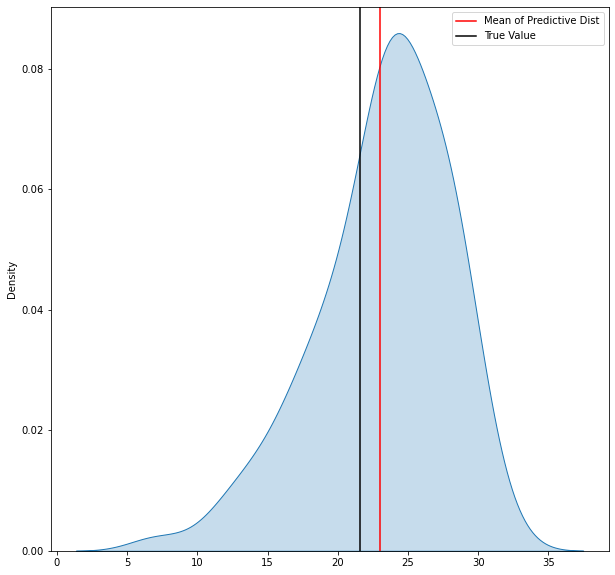

True value:  21.6
Mean of predictive distribution:  23.016817
Predicted value without dropout:  [19.201527]


In [15]:
#obtain predictions using mc dropout 
y_pred_dist = predict_dist(Xtest, model, 100)
y_pred = predict_point(Xtest, model, 100)

f = plt.figure()
f.set_figwidth(10)
f.set_figheight(10)

i=59
sns.kdeplot(y_pred_dist[i], shade=True)
plt.axvline(y_pred[i], color='red', label="Mean of Predictive Dist")
plt.axvline(Ytest[i], color='black', label="True Value")
plt.legend()
plt.show()

print("True value: ", Ytest[i])
print("Mean of predictive distribution: ", y_pred[i])
print("Predicted value without dropout: ", preds_nodropout[i])

#although the mean of the predictive distribution is close to the true value
#the model still produces a wide range of predictions 

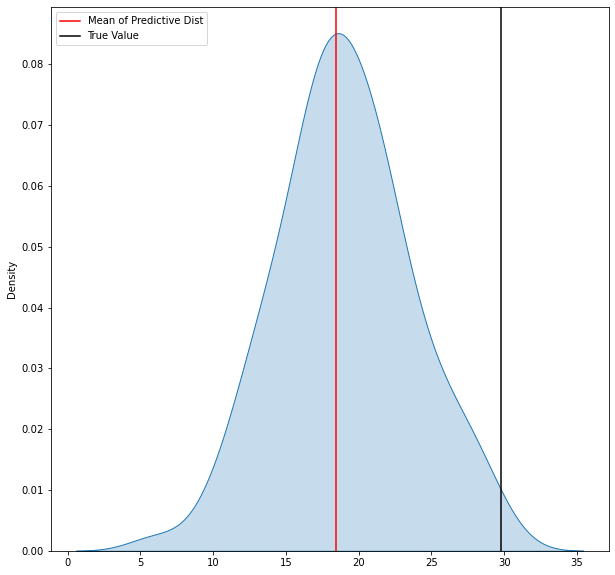

True value:  29.8
Mean of predictive distribution:  18.435719
Predicted value without dropout:  [14.613659]


In [16]:
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(10)

i=60
sns.kdeplot(y_pred_dist[i], shade=True)
plt.axvline(y_pred[i], color='red', label="Mean of Predictive Dist")
plt.axvline(Ytest[i], color='black', label="True Value")
plt.legend()
plt.show()

print("True value: ", Ytest[i])
print("Mean of predictive distribution: ", y_pred[i])
print("Predicted value without dropout: ", preds_nodropout[i])